## MLP using Sklearn

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy

In [2]:
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)

In [4]:
# load pima indians dataset
dataset = numpy.loadtxt("pima-indians-diabetes.csv", delimiter=",")
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
y = dataset[:,8]

In [5]:
# train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

In [6]:
#Normalization

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10),max_iter=1000, verbose=2)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.97322078
Iteration 2, loss = 0.95988981
Iteration 3, loss = 0.94696938
Iteration 4, loss = 0.93513825
Iteration 5, loss = 0.92364982
Iteration 6, loss = 0.91253170
Iteration 7, loss = 0.90252676
Iteration 8, loss = 0.89203360
Iteration 9, loss = 0.88301304
Iteration 10, loss = 0.87440040
Iteration 11, loss = 0.86560356
Iteration 12, loss = 0.85744149
Iteration 13, loss = 0.84999216
Iteration 14, loss = 0.84251866
Iteration 15, loss = 0.83473714
Iteration 16, loss = 0.82785462
Iteration 17, loss = 0.82033614
Iteration 18, loss = 0.81305501
Iteration 19, loss = 0.80620462
Iteration 20, loss = 0.79849013
Iteration 21, loss = 0.79150308
Iteration 22, loss = 0.78417821
Iteration 23, loss = 0.77650951
Iteration 24, loss = 0.76918459
Iteration 25, loss = 0.76178319
Iteration 26, loss = 0.75447200
Iteration 27, loss = 0.74629910
Iteration 28, loss = 0.73865381
Iteration 29, loss = 0.73028236
Iteration 30, loss = 0.72224070
Iteration 31, loss = 0.71389669
Iteration 32, los

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, verbose=2)

In [8]:
predictions = mlp.predict(X_test)


print("Accuracy", metrics.accuracy_score(y_test, predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy 0.75
[[139  28]
 [ 36  53]]
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81       167
         1.0       0.65      0.60      0.62        89

    accuracy                           0.75       256
   macro avg       0.72      0.71      0.72       256
weighted avg       0.75      0.75      0.75       256



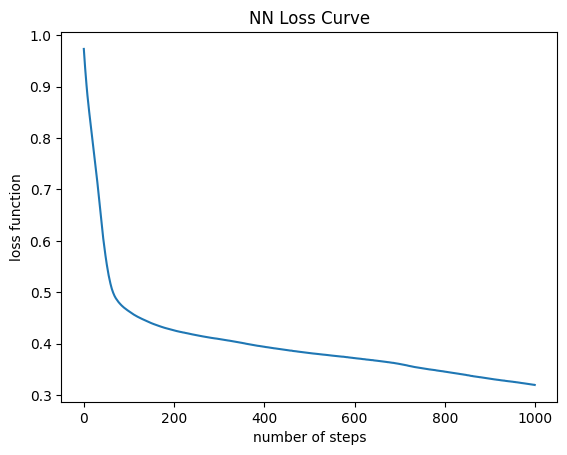

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(mlp.loss_curve_)
plt.title("NN Loss Curve")
plt.xlabel("number of steps")
plt.ylabel("loss function")
plt.show()

In [10]:
mlp.intercepts_[0]

array([-0.73789541,  0.19114027, -0.48111694,  0.22361436,  0.65651171,
       -0.45474338, -0.54173307,  0.57064626,  0.54775614,  0.82921315])

In [11]:
mlp.coefs_[0]

array([[-0.73573392,  0.66128634, -0.78235156,  0.17314407,  0.56630318,
        -0.04745308,  0.1541847 , -0.84996535, -0.27455765, -0.31934634],
       [-0.16934322,  0.45350596, -0.22837276, -0.48795453, -0.20501971,
         0.93258063, -0.05062183,  0.1248382 ,  0.83068277, -0.37446488],
       [-0.26183688,  0.23212921,  0.0786913 ,  0.45696004, -0.12769152,
        -0.30026327,  0.6870468 ,  0.09727278, -0.46978622,  0.10866209],
       [-0.55121076,  0.21640212,  0.04549597, -0.18711704,  0.17419767,
        -0.34648717,  0.39765556, -0.50946379,  0.14555434,  0.16947169],
       [ 0.0894359 , -0.27538532,  0.35227155,  0.22268251, -0.37159788,
         0.3810828 , -0.1610418 ,  0.62813312, -0.51018817,  0.05251514],
       [-0.24926178, -0.0901546 ,  0.58051514,  0.04252584, -0.29214173,
        -0.97597617, -0.44887814, -0.09461574,  0.53102923,  0.04457461],
       [ 0.56841192,  0.3113257 , -0.75733597, -0.17069777, -0.24707364,
        -0.1733464 ,  0.78796791,  0.0904021 

## MLP using keras

In [12]:
from keras.models import Sequential
from keras.layers import Dense


# create keras model
model = Sequential()
model.add(Dense(12, input_dim=8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))

print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

None


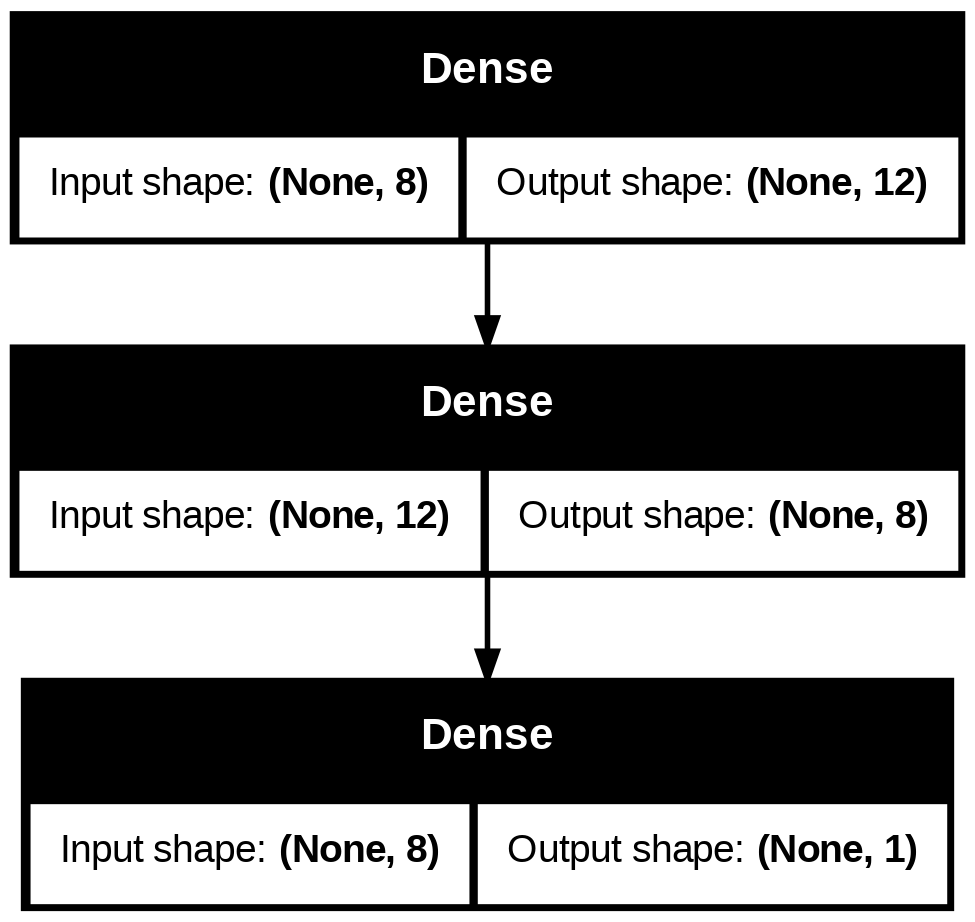

In [14]:
from keras.utils import plot_model
#from keras.utils.vis_utils import plot_model
import IPython
plot_model(model, to_file='model.png',show_shapes=True)
IPython.display.Image("model.png")

In [15]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Fit the model

history=model.fit(X_train, y_train, validation_split=0.25, epochs=80, batch_size=10)
# calculate predictions

Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.6525 - loss: 0.6917 - val_acc: 0.6172 - val_loss: 0.6884
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.6458 - loss: 0.6840 - val_acc: 0.6172 - val_loss: 0.6761
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6767 - loss: 0.6623 - val_acc: 0.6172 - val_loss: 0.6438
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6443 - loss: 0.6218 - val_acc: 0.6172 - val_loss: 0.6017
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6846 - loss: 0.5569 - val_acc: 0.6172 - val_loss: 0.5759
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6917 - loss: 0.4960 - val_acc: 0.6172 - val_loss: 0.5684
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6414 - loss: 0.5129 - val_acc: 0.6172 - val_loss: 0.5631
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6618 - loss: 0.5124 - val_acc: 0.6172 - val_loss: 0.5589
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6450 - loss:

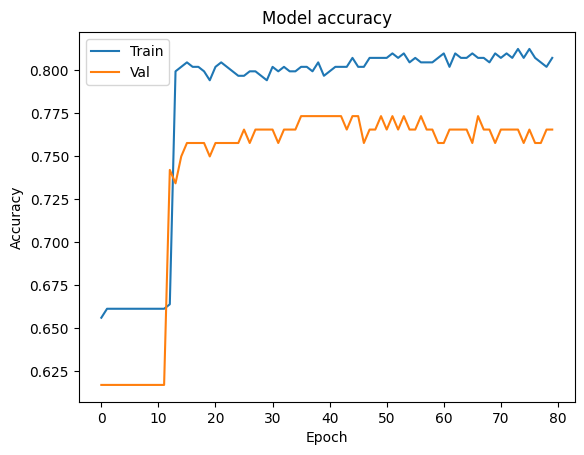

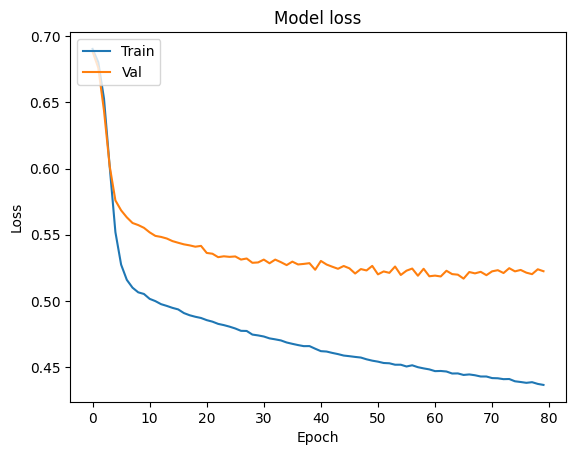

In [16]:
# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [17]:
for layer in model.layers:
    weights = layer.get_weights()
    print(weights)

[array([[ 0.0757174 ,  0.07215066,  0.07688951,  0.08455998, -0.18104365,
         0.10725603,  0.07673987, -0.2241271 ,  0.03508924, -0.24823904,
        -0.20511726, -0.06585483],
       [ 0.3525367 ,  0.35770455,  0.3520047 , -0.29040498, -0.35560924,
        -0.38466284,  0.36233264, -0.2568642 , -0.32341278, -0.19988176,
        -0.26949346, -0.27206084],
       [-0.09170482, -0.09265488, -0.09182285, -0.15327156,  0.1371055 ,
        -0.06986652, -0.08903375,  0.17957556, -0.04013889,  0.19894128,
         0.22302589,  0.24334176],
       [-0.12299938, -0.12288817, -0.12160835, -0.2670758 , -0.06496949,
        -0.18596755, -0.12361479,  0.046175  , -0.1439401 ,  0.05500039,
         0.03034513, -0.25831214],
       [-0.02060941, -0.01740551, -0.02074672,  0.26355806, -0.01085811,
        -0.03421934, -0.01650947, -0.3037017 , -0.01792213,  0.04787068,
        -0.27532694,  0.15859924],
       [ 0.21508485,  0.22267397,  0.21450506, -0.4224133 , -0.0722913 ,
        -0.1826205 , 

In [21]:
predictions = model.predict(X_test)
p_labels = [round(x[0]) for x in predictions]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [22]:
p_labels

[0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [23]:
print("Accuracy", metrics.accuracy_score(y_test, p_labels))
print(confusion_matrix(y_test,p_labels))
print(classification_report(y_test,p_labels))

Accuracy 0.765625
[[147  20]
 [ 40  49]]
              precision    recall  f1-score   support

         0.0       0.79      0.88      0.83       167
         1.0       0.71      0.55      0.62        89

    accuracy                           0.77       256
   macro avg       0.75      0.72      0.73       256
weighted avg       0.76      0.77      0.76       256

